# Project 3 - 2026

Work in groups of 2-5. Prepare ~10 slides where one slide describes your setup and analysis, main results, challenges/suprises and take-home message.

Everyone should do the first part of the project. You will be allocated one of the three themes for part 2 - check announcements on canvas to see which theme is allocated to your group.

You will be working with the Cats and Dogs data set and/or the MNIST data set.

For all tasks, you have to repeat the exercise in order to be able to draw conclusions. That is, one single run of a data analysis task or simulation has very limited information so repeat a few times to ensure you are not drawing conclusions based on a random "fluke". 

The most structured way to do this is Nested CV. That is, an outer K-fold split into training and test and an inner CV-loop for tuning models. However, you can also use repeated random splits into training and testing instead of CV. The benefit of using CV is that the correlation between the outer splits, but a large number of random splits might be more beneficial if you want to compare many models in an outer loop. 


In [14]:
# 

# First the cats and dogs data...
import pandas as pd 

PATHIM = "cnd_large//cnd_large//images.csv" 
PATHLB = "cnd_large//cnd_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels['label'].unique()}")

'images' size: (10000, 4096)
'labels' size: (10000, 1)
Classes [0 1]


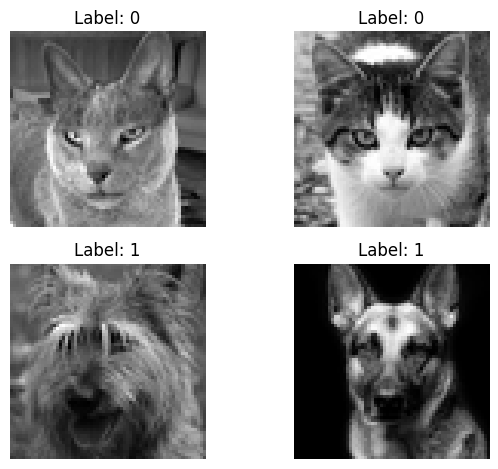

In [15]:
import matplotlib.pyplot as plt
import numpy as np

images = np.array(images)
labels = np.array(labels).ravel()

# Visualize some images (take two from each class):
catidx = np.where(labels == 0)[0]
dogidx = np.where(labels == 1)[0]

n_samples = 2

catsample = np.random.choice(catidx, size = n_samples, replace = False)
dogsample = np.random.choice(dogidx, size = n_samples, replace = False)

idx = np.concatenate([catsample, dogsample])
images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(2, 2)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(64,64)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

In [16]:
# ...then the numbers data
import pandas as pd

PATHIM = "mnist_large//images.csv"
PATHLB = "mnist_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels['label'].unique()}")

'images' size: (10000, 784)
'labels' size: (10000, 1)
Classes [0 1 2 3 4 5 6 7 8 9]


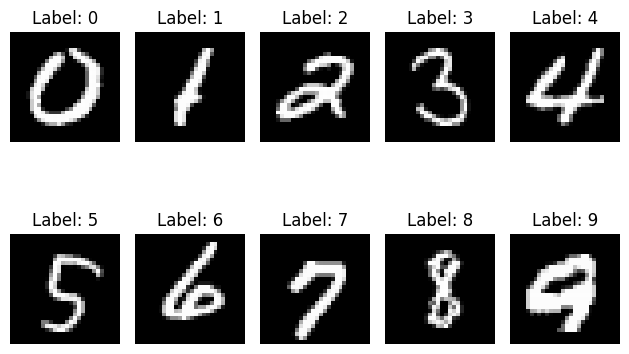

In [17]:
import matplotlib.pyplot as plt
import numpy as np

images = np.array(images)
labels = np.array(labels).ravel()

n_images = images.shape[0]

# Visualize the first images in each class
idx = [np.where(labels == i)[0][0] for i in range(10)]
images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(2, 5)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(28,28)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

# Part 1

*Everyone should do this task.*

For the first part, use the large cats and dogs dataset in order to investigate the effects of varying the sample size (n) on the method.

Use at least 4 classifiers and make sure they span a spectrum from rigid to flexible. 

Compare the Performance: Measure the performance in each method as you decrease the sample size. Also compare the performance across methods.
You should use at least 2 performance metrics, e.g. accuracy, log-loss/cross-entropy, Brier score  ($\frac{1}{N}\sum_{i=1}^N\sum_{k=1}^K (\hat{p}_{ik}-y_{ik})^2$, where $y_{ik}=1$ when observation $i$ belongs to class k, and 0 otherwise), balanced accuracy, F1-macro, etc. The first 3 are more commonly used to compare models through repeated data splits because they mesh well with testing procedures. 

WE WILL TALK ABOUT THE FOLLOWING IN CLASS NEXT WEEK: I recommend you use rank-based tests to compare the models. That is, for each data split, obtain the ranks for all the models. Use the Friedman test to determine if there are any significant differences between model performance. If there is, perform all pairwise tests between models and adjust using the Holm procedure. Now you can either visualize these p-values in a M-by-M heat map (M models) or in a table with equivalent rank groups (e.g. Model 1, Model 3 > Model 2 > Model 4, Model 5). In Python, the \verbatim{scikit_posthocs} package has some of this implemented but you can also code from scratch. The Friedman-allpairsexact test is not available but you can use Nemenyi instead although it is more conservative.  A Bayesian variant allows for another way to create equivalent ranks through - this is implemented in a package called \verbatim{baycomp}. 

Be prepare to explain:
Which method was best and how did you evaluate this?
Did any method suprise you? 
What was your pipeline? 



In [18]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score

def evaluate_pipeline_with_outer_inner_cv(pipeline,params, X, y, sample_size, outer_folds, inner_folds, seed=42):
    np.random.seed(seed)
    outer_cv = StratifiedKFold(n_splits=outer_folds, shuffle=True, random_state=seed)
    X_sample, _, y_sample, _ = train_test_split(X, y, train_size=sample_size, stratify=y, random_state=seed)
    outer_accuracies = []
    outer_f1_scores = []
    for train_idx, test_idx in outer_cv.split(X_sample, y_sample):
        X_train, X_test = X_sample[train_idx], X_sample[test_idx]
        y_train, y_test = y_sample[train_idx], y_sample[test_idx]
        
        inner_cv = StratifiedKFold(n_splits=inner_folds, shuffle=True, random_state=seed)
        grid_search = GridSearchCV(estimator=pipeline, param_grid=params, cv=inner_cv, scoring=['accuracy', 'f1_macro'], refit='accuracy')
        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        outer_accuracies.append(acc)
        outer_f1_scores.append(f1)

    return outer_accuracies, outer_f1_scores


In [19]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

pipeline = Pipeline([
    ('pca', PCA()),
    ('xgb', XGBClassifier(eval_metric='logloss'))
])

params = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 5],
    'xgb__learning_rate': [0.01, 0.1],
    'pca__n_components': [0.1, 0.25, 0.5],
}

for sample_size in [100, 500, 1000]:
    for seed in [42, 99]:
        accs, f1s = evaluate_pipeline_with_outer_inner_cv(pipeline, params, images, labels, sample_size, outer_folds=5, inner_folds=3, seed=seed)
        print(f"Sample size: {sample_size}, Seed: {seed}, Accuracy: {np.mean(accs):.4f} ± {np.std(accs):.4f}, F1-score: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")

KeyboardInterrupt: 

## Method comparison with repeated nested CV + Friedman ranks

We compare four classifiers spanning *rigid → flexible*:

- **Logistic Regression** (rigid, linear)
- **KNN** (non-parametric, locally flexible)
- **Random Forest** (ensemble of trees)
- **XGBoost** (gradient boosted trees)

Structure per the lecture: repeat **R** times, each repetition runs **K-fold outer CV**;
the train portion of each outer fold is fed to **L-fold inner CV** for hyper-parameter
tuning. All four methods are evaluated on the *same* outer folds so the resulting
`R·K × M` score matrix `P` is paired and suitable for the Friedman rank test.


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from xgboost import XGBClassifier


def make_methods():
    lr = Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('pca', PCA(n_components=0.9, random_state=0)),
        ('clf', LogisticRegression(max_iter=2000, solver='lbfgs')),
    ])
    lr_grid = {'clf__C': [0.01, 0.1, 1.0, 10.0]}

    knn = Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('pca', PCA(n_components=0.9, random_state=0)),
        ('clf', KNeighborsClassifier(n_jobs=-1)),
    ])
    knn_grid = {'clf__n_neighbors': [3, 5, 11, 21]}

    rf = Pipeline([
        ('pca', PCA(n_components=0.9, random_state=0)),
        ('clf', RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=0)),
    ])
    rf_grid = {'clf__max_depth': [None, 10, 20], 'clf__min_samples_leaf': [1, 5]}

    xgb = Pipeline([
        ('pca', PCA(n_components=0.9, random_state=0)),
        ('clf', XGBClassifier(eval_metric='logloss', n_jobs=-1, verbosity=0,
                              tree_method='hist', random_state=0)),
    ])
    xgb_grid = {
        'clf__n_estimators': [100, 200],
        'clf__max_depth':    [3, 5],
        'clf__learning_rate':[0.05, 0.1],
    }

    return {
        'LogReg':  (lr,  lr_grid),
        'KNN':     (knn, knn_grid),
        'RF':      (rf,  rf_grid),
        'XGBoost': (xgb, xgb_grid),
    }


In [21]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, f1_score
import time


def repeated_nested_cv(methods, X, y, sample_size, R=3, K=5, L=3, base_seed=42, verbose=True):
    """Run R repeats of K-fold outer CV, with L-fold inner CV for tuning each method.

    Returns
    -------
    acc : ndarray (R*K, M) – accuracy on each outer test fold per method
    f1  : ndarray (R*K, M) – macro-F1 on each outer test fold per method
    names : list[str] of method names (column order of acc / f1)
    """
    names = list(methods.keys())
    M = len(names)

    # Sub-sample once, deterministically, so all (R, K, method) splits see the same pool
    X_use, _, y_use, _ = train_test_split(
        X, y, train_size=sample_size, stratify=y, random_state=base_seed)

    acc = np.zeros((R * K, M))
    f1  = np.zeros((R * K, M))

    row = 0
    for r in range(R):
        seed_r = base_seed + r
        outer = StratifiedKFold(n_splits=K, shuffle=True, random_state=seed_r)
        for k, (tr, te) in enumerate(outer.split(X_use, y_use)):
            X_tr, X_te = X_use[tr], X_use[te]
            y_tr, y_te = y_use[tr], y_use[te]
            inner = StratifiedKFold(n_splits=L, shuffle=True, random_state=seed_r + 1000)

            for m, name in enumerate(names):
                pipe, grid = methods[name]
                t0 = time.time()
                gs = GridSearchCV(pipe, grid, cv=inner, scoring='accuracy', n_jobs=-1)
                gs.fit(X_tr, y_tr)
                yhat = gs.predict(X_te)
                acc[row, m] = accuracy_score(y_te, yhat)
                f1[row, m]  = f1_score(y_te, yhat, average='macro')
                if verbose:
                    print(f"  r={r+1}/{R} k={k+1}/{K} {name:<8s} "
                          f"acc={acc[row, m]:.3f} f1={f1[row, m]:.3f} "
                          f"({time.time()-t0:.1f}s)")
            row += 1

    return acc, f1, names


In [22]:
# Run the comparison. Use a modest sample_size so it finishes in reasonable time.
# Scale up R, K, L, sample_size on a beefier run.
SAMPLE_SIZE = 1000
R, K, L = 3, 5, 3

methods = make_methods()
acc_mat, f1_mat, method_names = repeated_nested_cv(
    methods, images, labels, sample_size=SAMPLE_SIZE, R=R, K=K, L=L, base_seed=42)

print()
print(f"Score matrix shape: {acc_mat.shape}  (R*K rows × M methods)")
print(f"Methods: {method_names}")
print()
print("Mean ± std accuracy per method:")
for m, name in enumerate(method_names):
    print(f"  {name:<8s} {acc_mat[:, m].mean():.4f} ± {acc_mat[:, m].std():.4f}")
print()
print("Mean ± std F1-macro per method:")
for m, name in enumerate(method_names):
    print(f"  {name:<8s} {f1_mat[:, m].mean():.4f} ± {f1_mat[:, m].std():.4f}")


  r=1/3 k=1/5 LogReg   acc=0.880 f1=0.880 (3.0s)
  r=1/3 k=1/5 KNN      acc=0.840 f1=0.840 (1.9s)
  r=1/3 k=1/5 RF       acc=0.835 f1=0.836 (2.8s)
  r=1/3 k=1/5 XGBoost  acc=0.845 f1=0.845 (16.5s)
  r=1/3 k=2/5 LogReg   acc=0.850 f1=0.850 (1.0s)
  r=1/3 k=2/5 KNN      acc=0.790 f1=0.787 (1.2s)
  r=1/3 k=2/5 RF       acc=0.860 f1=0.859 (2.9s)
  r=1/3 k=2/5 XGBoost  acc=0.835 f1=0.832 (15.5s)
  r=1/3 k=3/5 LogReg   acc=0.880 f1=0.879 (0.9s)
  r=1/3 k=3/5 KNN      acc=0.850 f1=0.850 (1.0s)
  r=1/3 k=3/5 RF       acc=0.875 f1=0.873 (2.8s)
  r=1/3 k=3/5 XGBoost  acc=0.835 f1=0.834 (15.4s)
  r=1/3 k=4/5 LogReg   acc=0.865 f1=0.865 (1.0s)
  r=1/3 k=4/5 KNN      acc=0.825 f1=0.825 (1.0s)
  r=1/3 k=4/5 RF       acc=0.860 f1=0.860 (2.8s)
  r=1/3 k=4/5 XGBoost  acc=0.815 f1=0.816 (15.5s)
  r=1/3 k=5/5 LogReg   acc=0.865 f1=0.863 (0.9s)
  r=1/3 k=5/5 KNN      acc=0.825 f1=0.822 (1.0s)
  r=1/3 k=5/5 RF       acc=0.850 f1=0.850 (2.8s)
  r=1/3 k=5/5 XGBoost  acc=0.825 f1=0.825 (15.5s)
  r=2/3 k=1/5 L

=== Accuracy ===
Friedman χ² = 27.9796,  p = 3.668e-06  (reject H0 of equal performance)
Average rank (1 = best):
  LogReg   1.300
  RF       2.133
  XGBoost  2.933
  KNN      3.633


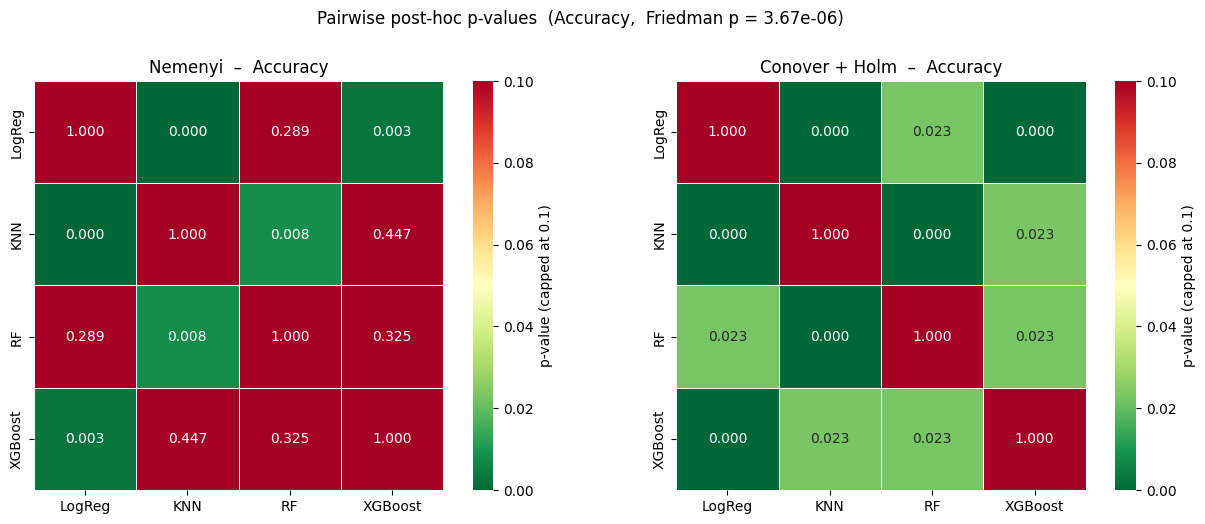

=== F1-macro ===
Friedman χ² = 26.9200,  p = 6.119e-06  (reject H0 of equal performance)
Average rank (1 = best):
  LogReg   1.333
  RF       2.133
  XGBoost  2.867
  KNN      3.667


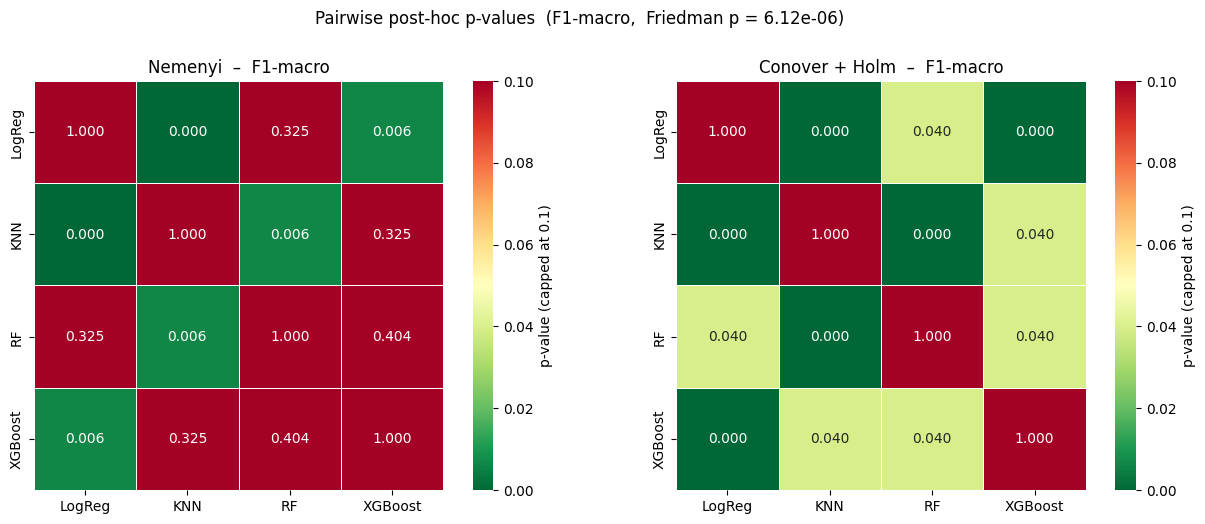

In [26]:
# Friedman rank test + Nemenyi / Conover-Holm post-hoc + heatmaps.
# Install once if needed:  pip install scikit-posthocs
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare, rankdata
import scikit_posthocs as sp


def friedman_and_heatmaps(score_matrix, method_names, score_name='Accuracy',
                          higher_is_better=True, alpha=0.05):
    M = score_matrix.shape[1]
    stat, p_friedman = friedmanchisquare(*[score_matrix[:, m] for m in range(M)])

    # Average ranks (rank 1 = best). If higher score is better, negate before ranking.
    sgn = -1 if higher_is_better else 1
    ranks = np.array([rankdata(sgn * row) for row in score_matrix])
    avg_ranks = ranks.mean(axis=0)
    rank_order = np.argsort(avg_ranks)

    print(f"=== {score_name} ===")
    print(f"Friedman χ² = {stat:.4f},  p = {p_friedman:.4g}  "
          f"({'reject H0 of equal performance' if p_friedman < alpha else 'fail to reject H0'})")
    print("Average rank (1 = best):")
    for i in rank_order:
        print(f"  {method_names[i]:<8s} {avg_ranks[i]:.3f}")

    df = pd.DataFrame(score_matrix, columns=method_names)
    nemenyi_p = sp.posthoc_nemenyi_friedman(df)
    conover_p = sp.posthoc_conover_friedman(df, p_adjust='holm')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, mat, title in zip(
        axes, [nemenyi_p, conover_p],
        [f'Nemenyi  –  {score_name}', f'Conover + Holm  –  {score_name}']):
        sns.heatmap(mat, annot=True, fmt='.3f', cmap='RdYlGn_r',
                    vmin=0, vmax=0.1, cbar_kws={'label': 'p-value (capped at 0.1)'},
                    ax=ax, square=True, linewidths=0.5)
        ax.set_title(title)
    plt.suptitle(f'Pairwise post-hoc p-values  ({score_name},  Friedman p = {p_friedman:.3g})',
                 y=1.02)
    plt.tight_layout()
    plt.show()

    return {
        'friedman_stat': stat, 'friedman_p': p_friedman,
        'avg_ranks': dict(zip(method_names, avg_ranks)),
        'nemenyi_p': nemenyi_p, 'conover_p': conover_p,
    }


acc_results = friedman_and_heatmaps(acc_mat, method_names, score_name='Accuracy')
f1_results  = friedman_and_heatmaps(f1_mat,  method_names, score_name='F1-macro')


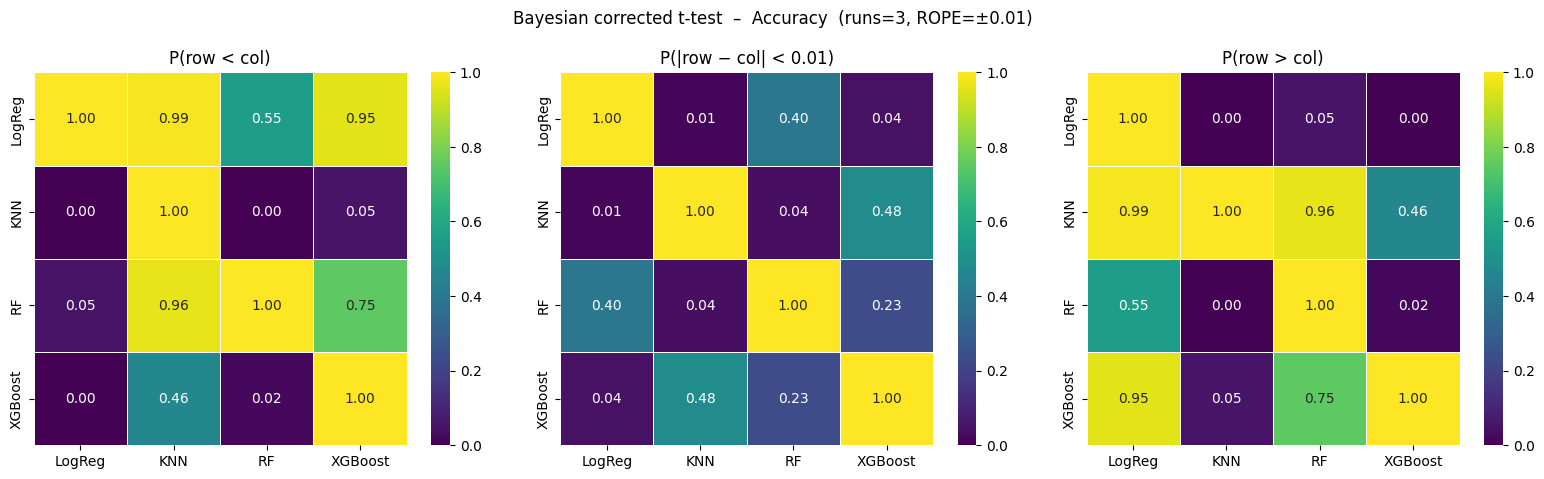

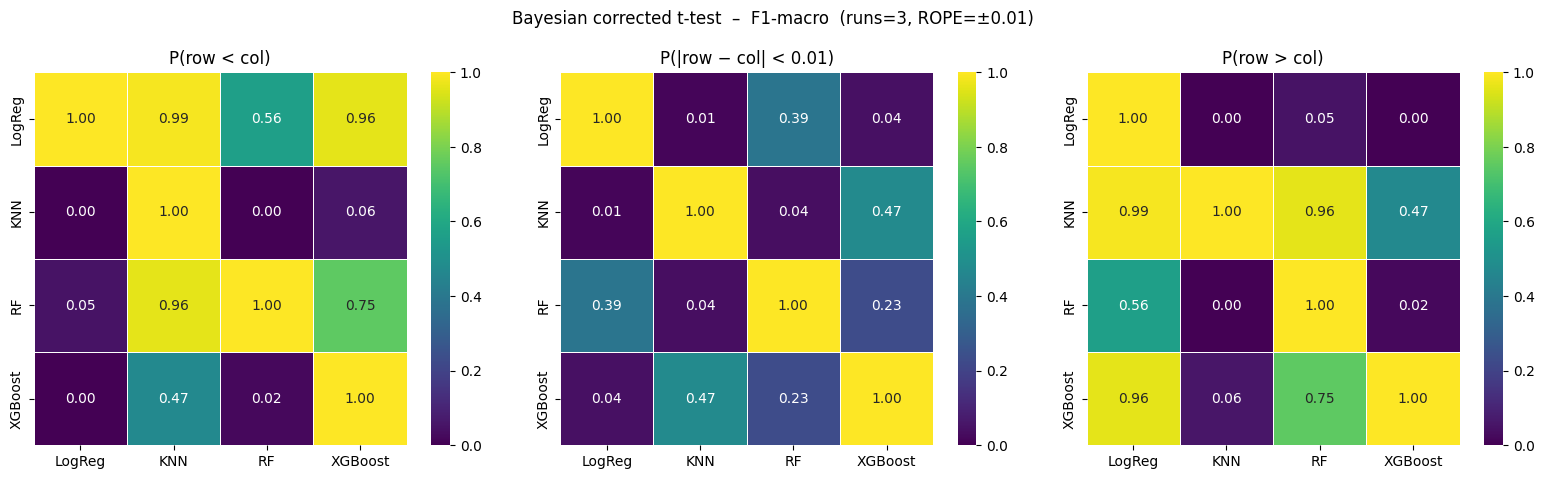

In [27]:
# Bayesian corrected t-test (baycomp) – accounts for the R-repeated K-fold
# correlation structure via the runs= parameter. Install once: pip install baycomp
import baycomp

def baycomp_heatmap(score_matrix, method_names, runs, rope=0.01, score_name='Accuracy'):
    M = len(method_names)
    p_left  = np.eye(M)
    p_rope  = np.eye(M)
    p_right = np.eye(M)
    for i in range(M):
        for j in range(M):
            if i == j:
                continue
            pl, pr_, pright = baycomp.two_on_single(
                score_matrix[:, i], score_matrix[:, j], rope=rope, runs=runs)
            p_left[i, j]  = pl
            p_rope[i, j]  = pr_
            p_right[i, j] = pright

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for ax, mat, title in zip(
        axes,
        [p_left, p_rope, p_right],
        ['P(row < col)', f'P(|row − col| < {rope})', 'P(row > col)']):
        sns.heatmap(pd.DataFrame(mat, index=method_names, columns=method_names),
                    annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1,
                    ax=ax, square=True, linewidths=0.5)
        ax.set_title(title)
    plt.suptitle(f'Bayesian corrected t-test  –  {score_name}  (runs={runs}, ROPE=±{rope})',
                 y=1.02)
    plt.tight_layout()
    plt.show()

    return {'p_left': p_left, 'p_rope': p_rope, 'p_right': p_right}


baycomp_acc = baycomp_heatmap(acc_mat, method_names, runs=R, rope=0.01, score_name='Accuracy')
baycomp_f1  = baycomp_heatmap(f1_mat,  method_names, runs=R, rope=0.01, score_name='F1-macro')


## Part 2 - Themes
You will be allocated one of the three themes and should perform ***all*** tasks as described in this theme.

### Theme 1 - Imbalance
Use the Cats and Dogs dataset.

Investigate the effects of imbalance on PART 1 - where you create the imbalance. Try with different train, calibration and test sizes. 

Does the model ranking change?

### Theme 2 - Conformal Prediction
Use the MNIST data set.

Select 3 classifiers. Perform conformal prediction. Do you observe similar conformal predictions between the methods? Summarize the conformal predictions. Are certain classes more often to be lumped together in the same set of predictions and does it depend on the classifier used? 

Try with different train, calibration and test sizes. 

### Theme 3 - Mislabeling

Create a mislabeled data set from the digits data by randomly changing the labels for some of the observations. *Note, you should only create mislabels for your training data - the test data should be clean.*

Redo Part 1 in this setting.

Which methods handle the mislabeling OK? Which methods struggle? How does sample size affect this?

You should explore at least 3 levels of mislabeling (some modest, some more severe and some really severe cases), i.e. proportion of mislabeled data. *Please note that your test data should be "clean", i.e. without mislabeling*. For each simulation run, make sure you create a clean and separate data set to estimate prediction performance.

Do the above on 3 levels of data (full data, medium data, small data).